# Lab — Summary-backed multimodal RAG : solution des huit exercices

Le notebook fourni porte sur **CJ.pdf / Clouded Judgement**, malgré le nom du dossier. Cette version implémente le parcours complet et les huit exercices : ablation des prompts, sweep de k, audit de cinq questions, routage, cache par élément, DPI, Library of Congress et entailment des citations. Une intégration LangSmith est également fournie.

**Mode local :** extraction et rendu du vrai PDF, index vectoriel TF-IDF, jointure vers les originaux, contrôles de provenance et cache. Les proxys d’images locaux sont du texte extrait, pas des descriptions produites par vision. **Mode OpenAI :** résumés visuels et réponses multimodales avec les modèles du support. Le backend local remplace Chroma par des vecteurs TF-IDF cosinus, avec persistance conjointe des résumés et des originaux ; les performances ne sont donc pas assimilées à celles d’OpenAI Embeddings.

Les valeurs financières sont celles de l’édition du 10 novembre 2023, pas des données de marché actuelles.


In [1]:
# Installation : %pip install -r requirements.txt
# Poppler doit être disponible (macOS : brew install poppler).
import os,json
from pathlib import Path
import pandas as pd
from PIL import Image
from IPython.display import display
from dotenv import load_dotenv
load_dotenv()
MODE='local'  # 'openai' pour les résumés et réponses réels
RUN_LANGSMITH=False
from summary_lab import *
PDF_PATH=Path(os.getenv('PDF_PATH','CJ.pdf'))
LCM_PATH=Path(os.getenv('LCM_PATH','LCM_2020_1112.pdf'))
RENDER_DPI=200
print('Mode :',MODE,'; PDF :',PDF_PATH)


Mode : local ; PDF : CJ.pdf


## Extraction, rendu et index des proxys


In [2]:
items=extract_pdf(PDF_PATH,dpi=RENDER_DPI)
records=summarize(items,mode=MODE)
index=SummaryIndex(records)
index.save(Path('work/index.json'))
reloaded=SummaryIndex.load(Path('work/index.json'))
print('Pages :',len({r['page'] for r in items}),' ; originaux :',len(items))
print('Index chargé après persistance :',len(reloaded.records))
assert [r['original_id'] for r in index.retrieve(NUMERIC_QUERY)]==[r['original_id'] for r in reloaded.retrieve(NUMERIC_QUERY)]


Pages : 14  ; originaux : 30
Index chargé après persistance : 30


## Inspection des preuves originales


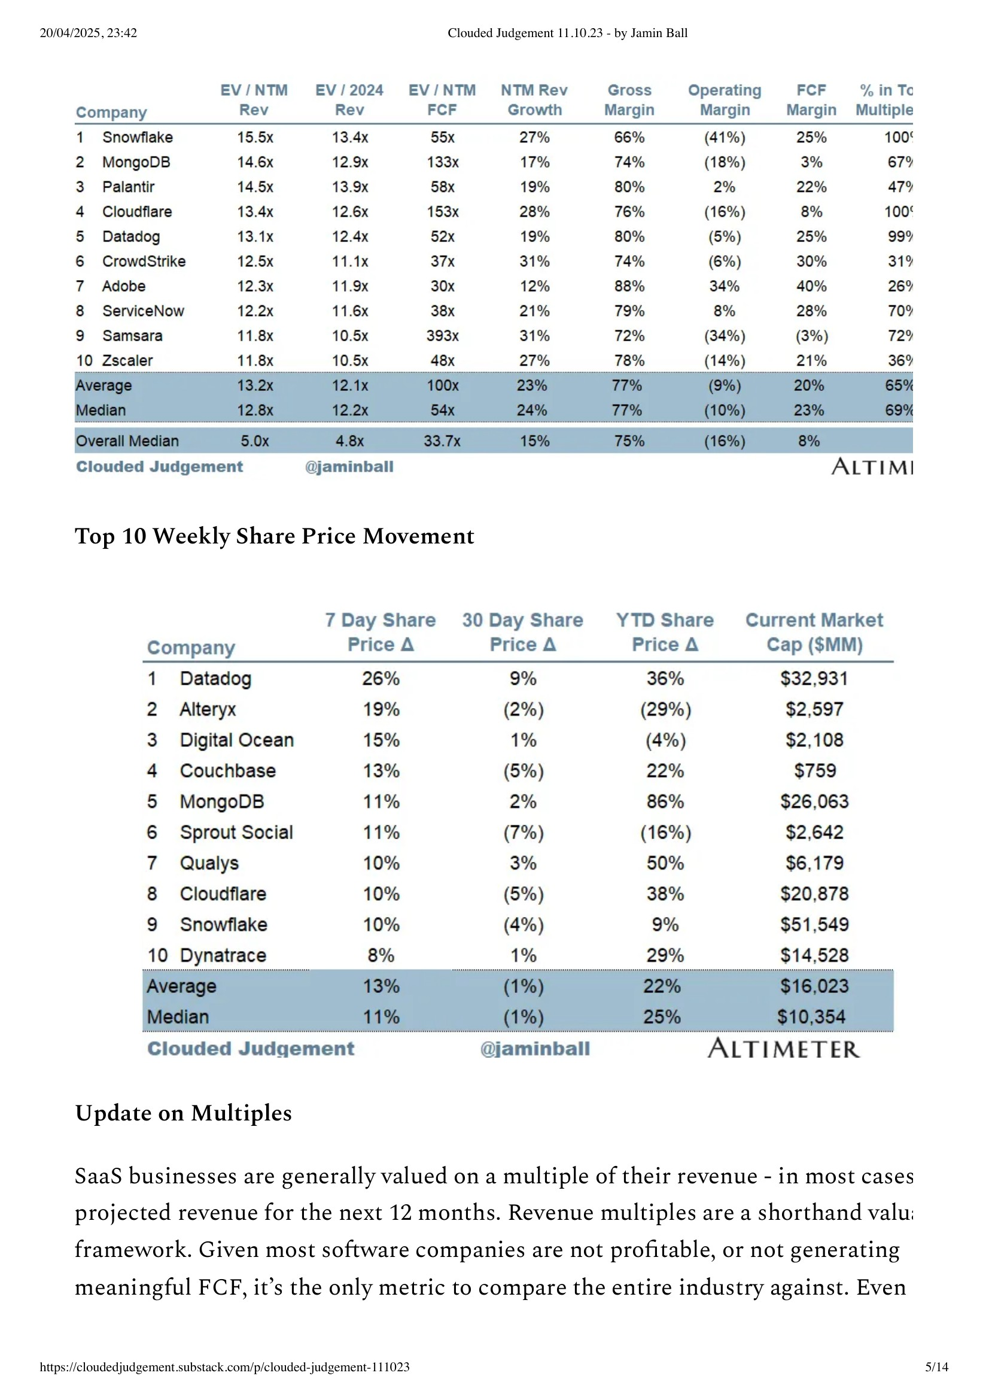

,rank,page,modality,distance
0,1,10,text,0.647297
1,2,10,image,0.647297
2,3,8,text,0.737607
3,4,8,image,0.737607
4,5,9,text,0.885918
5,6,9,image,0.885918
6,7,4,text,0.909901
7,8,4,image,0.909901
8,9,11,text,0.917816
9,10,11,image,0.917816


In [3]:
page5=next(r for r in items if r['modality']=='image' and r['page']==5)
preview=Image.open(page5['content']).copy();preview.thumbnail((1000,1400))
display(preview)
hits=index.retrieve(NUMERIC_QUERY,k=10)
display(pd.DataFrame([{key:r[key] for key in ['rank','page','modality','distance']} for r in hits]))


**Référence vérifiée visuellement, page 5 :** MongoDB : EV/NTM 14,6× et croissance NTM 17 % ; Cloudflare : 13,4× et 28 % ; Datadog : 13,1× et 19 %. Cette référence sert à l’évaluation ; elle n’est jamais injectée dans la recherche ou le prompt de réponse.

Le texte extrait de cette page ne contient pas ces lignes de tableau : la branche visuelle est donc utile. Le rendu montre aussi que le document d’origine est rogné à droite ; augmenter le DPI ne restaure pas une colonne située hors page.


# Exercises

## ESSENTIAL — 1. Summary-prompt ablation
Choose five image pages.

Index them twice:
1. current retrieval-specific summary;
2. `"Describe this image."`

Run the MongoDB/Cloudflare/Datadog query against both collections and compare ranks.

## ESSENTIAL — 2. k sweep
Run `k ∈ {3, 6, 10, 15}`.

Record:
- number of text results;
- number of image results;
- unique pages;
- whether the final answer changes.

More context is not automatically better.

## ESSENTIAL — 3. Citation audit
Ask five questions. For every answer:
- verify all claimed pages were **sent** (not merely retrieved);
- manually inspect whether each cited page actually supports the answer.

Distinguish **provenance** from **entailment**.

## PRODUCTION EXTENSION — 4. Query routing
Classify each question as:
- narrative;
- numeric/table/chart;
- visually descriptive.

Then change retrieval strategy or `max_images` accordingly.

## PRODUCTION EXTENSION — 5. Smarter cache invalidation
The notebook already caches summaries keyed by a hash of the PDF, model, prompt version, and DPI. Extend it to **per-item** caching so that appending one page to the PDF re-summarises only the new page instead of everything. What should the per-item key contain?

## PRODUCTION EXTENSION — 6. DPI ablation
Re-render the pages at 100, 150, and 200 DPI and re-run the numeric query at each setting. At which DPI does the model start refusing (or worse, guessing) table values? Relate the result to the "don't guess illegible numbers" instruction.

## CHALLENGE — 7. Run the original Library of Congress example
Use `LCM_2020_1112.pdf`.

Ask:

> What does this issue say about "American Gothic" and "Not an Ostrich"?

Compare its modality mix with the financial PDF.

## CHALLENGE — 8. Add citation entailment
For each cited page, run a second evaluator asking:

> Does this page directly support the associated claim?

Now your pipeline has:
- retrieval;
- answer generation;
- provenance validation;
- semantic citation validation.


## Solution 1 — Deux prompts, les mêmes cinq pages


In [4]:
prompt_ablation=ablate_prompts(items,mode=MODE,pages=(4,5,7,10,12))
display(pd.DataFrame(prompt_ablation))
if MODE=='openai':
    display(pd.DataFrame(prompt_ablation).pivot(index='page',columns='variant',values='rank'))


,status,reason,pages
0,not_run,Two vision-prompt variants require the model,"[4, 5, 7, 10, 12]"


On garde les cinq pages, le modèle et le backend de recherche constants. La page 5 est une preuve connue pour la question numérique ; son rang peut être comparé entre les deux collections. En mode local, l’ablation de prompts n’est pas simulée : sans résumeur visuel, il n’y aurait pas de véritable différence de prompts à mesurer.


## Solution 2 — k = 3, 6, 10, 15


In [5]:
sweep=k_sweep(index,mode=MODE)
display(pd.DataFrame(sweep))


,k,text_results,image_results,unique_pages,sent_pages,answer_changed_exactly,answer,status
0,3,2,1,"[8, 10]","[8, 10]",None,NOT RUN: local retrieval only; no multimodal m...,retrieval_only
1,6,3,3,"[8, 9, 10]","[8, 9, 10]",None,NOT RUN: local retrieval only; no multimodal m...,retrieval_only
2,10,5,5,"[4, 8, 9, 10, 11]","[4, 8, 9, 10, 11]",None,NOT RUN: local retrieval only; no multimodal m...,retrieval_only
3,15,8,7,"[3, 4, 6, 7, 8, 9, 10, 11]","[4, 7, 8, 9, 10, 11]",None,NOT RUN: local retrieval only; no multimodal m...,retrieval_only


Les nombres de résultats concernent le retriever ; `sent_pages` tient compte des plafonds de texte et d’images. En mode OpenAI, le changement de réponse est une comparaison exacte avec la réponse à k=3 ; une différence de formulation n’est pas nécessairement une différence de fond.


## Solution 3 — Cinq questions, provenance et revue manuelle


In [6]:
audits=five_question_audit(index,mode=MODE)
display(pd.DataFrame([{'question':r['question'],'sent_pages':r['sent_pages'],**r['audit'],'manual_entailment':r['manual_entailment']} for r in audits]))


,question,sent_pages,invalid_pages,provenance_valid,cited_anything,claim_citations_consistent,all_claims_cited,entailment,manual_entailment
0,What are the EV / NTM and NTM rev growth for M...,"[4, 8, 9, 10, 11]",[],True,False,True,True,not_evaluated,pending — inspect cited pages against each claim
1,What are the five AI monetization layers descr...,"[1, 2, 3, 13]",[],True,False,True,True,not_evaluated,pending — inspect cited pages against each claim
2,What does Datadog say about customer optimizat...,"[1, 2, 3, 4, 12]",[],True,False,True,True,not_evaluated,pending — inspect cited pages against each claim
3,"What are the high, mid and low growth median m...","[5, 6, 7, 10, 11]",[],True,False,True,True,not_evaluated,pending — inspect cited pages against each claim
4,What are the median gross margin and net reten...,"[2, 6, 7, 10, 11]",[],True,False,True,True,not_evaluated,pending — inspect cited pages against each claim


La vérification porte sur les pages **envoyées**, pas sur toutes les pages retrouvées. Une liste de citations vide est signalée séparément. La revue manuelle reste à effectuer sur les réponses réelles : vérifier chaque affirmation face à l’image ou au texte cité, sans confondre présence de la page et soutien de la proposition.

Repères pour la revue : tableau des entreprises page 5 ; couches de monétisation page 1 ; commentaires Datadog pages 3–4 ; médianes par croissance page 7 ; marge brute et rétention page 11.


## Solution 4 — Routage selon la question


In [7]:
for q in QUESTIONS+['What does the cover look like?']:
    print(q,route_query(q))
routed=answer_pdf(index,NUMERIC_QUERY,mode=MODE,use_routing=True)
print('Pages envoyées avec routage :',routed['sent_pages'])


What are the EV / NTM and NTM rev growth for MongoDB, Cloudflare, and Datadog? {'route': 'numeric', 'max_text': 3, 'max_images': 5}
What are the five AI monetization layers described in this issue? {'route': 'narrative', 'max_text': 6, 'max_images': 1}
What does Datadog say about customer optimizations? {'route': 'narrative', 'max_text': 6, 'max_images': 1}
What are the high, mid and low growth median multiples? {'route': 'numeric', 'max_text': 3, 'max_images': 5}
What are the median gross margin and net retention? {'route': 'numeric', 'max_text': 3, 'max_images': 5}
What does the cover look like? {'route': 'visual', 'max_text': 1, 'max_images': 5}
Pages envoyées avec routage : [4, 8, 9, 10, 11]


Le routage numérique/visuel réserve un groupe de résultats image avant l’application des plafonds. Il peut améliorer la couverture visuelle, mais le classifieur lexical est limité : les mots ambigus doivent être contrôlés sur d’autres questions.


## Solution 5 — Invalidation par élément


In [8]:
key1=item_cache_key(page5,SUMMARY_MODEL,RETRIEVAL_PROMPT)
renumbered={**page5,'page':99,'original_id':'image-p99'}
assert key1==item_cache_key(renumbered,SUMMARY_MODEL,RETRIEVAL_PROMPT)
assert key1!=item_cache_key(page5,SUMMARY_MODEL,GENERIC_PROMPT)
print('Clé stable si seul le numéro de page change ; invalidée si le prompt change.')


Clé stable si seul le numéro de page change ; invalidée si le prompt change.


La clé contient le hash du contenu exact, la modalité, le modèle, le prompt complet, le DPI et les paramètres de rendu. Elle exclut le hash global du PDF et le numéro de page : ajouter une page ne force pas le recalcul des résumés inchangés. L’extraction et le rendu peuvent encore être refaits ; c’est le cache des appels de résumé qui est incrémental. Les deux côtés de la jointure sont sauvegardés dans le même bundle.


## Solution 6 — Ablation de résolution 100 / 150 / 200 DPI


In [9]:
dpi_results=dpi_ablation(PDF_PATH,mode=MODE)
display(pd.DataFrame(dpi_results))


,dpi,status,reason
0,100,not_run,Vision inference needed to compare refusal or ...
1,150,not_run,Vision inference needed to compare refusal or ...
2,200,not_run,Vision inference needed to compare refusal or ...


Les résumés et la sélection des pages restent fixes pour isoler l’effet du DPI sur la lecture des preuves par le modèle. Les réponses, limitations et contrôles numériques sont sauvegardés. Aucun seuil de refus n’est annoncé sans inférence ; une citation valide ne garantit pas la lecture correcte d’un chiffre.


## Solution 7 — Library of Congress


In [10]:
lcm_result=run_lcm(LCM_PATH,mode=MODE)
print(json.dumps(lcm_result,indent=2,ensure_ascii=False))
if lcm_result['status']!='not_run':
    print('CJ mix :',{'text_results':sum(r['modality']=='text' for r in routed['retrieved']),'image_results':sum(r['modality']=='image' for r in routed['retrieved'])})


{
  "status": "not_run",
  "reason": "LCM_2020_1112.pdf absent; set LCM_PATH to its location."
}


La fonction est prête pour `LCM_2020_1112.pdf`. Ce second PDF n’est pas fourni ; aucune conclusion sur American Gothic ou Not an Ostrich n’est fabriquée. Renseigner `LCM_PATH` puis relancer permet de comparer son mélange de modalités à celui du PDF financier.


[PDF officiel Library of Congress](https://www.loc.gov/lcm/pdf/LCM_2020_1112.pdf). La page officielle est accessible, mais le téléchargement automatique a renvoyé HTTP 403 dans cet environnement.


## Solution 8 — Entailment par affirmation et page


In [11]:
if MODE=='openai':
    entailment_results=evaluate_entailment(routed)
    display(pd.DataFrame(entailment_results))
else:
    entailment_results=[]
    print('Évaluateur sémantique non exécuté. Les tests de provenance restent disponibles.')


Évaluateur sémantique non exécuté. Les tests de provenance restent disponibles.


Chaque affirmation structurée porte ses pages. Le second modèle reçoit l’affirmation et uniquement les preuves de la page correspondante ; il renvoie supported, unsupported ou unclear. Ce juge peut lui-même se tromper : une validation humaine reste utile, notamment pour les tableaux. Le champ libre `answer` doit aussi être relu pour vérifier qu’il ne contient pas d’affirmations supplémentaires absentes de `claims`.


## LangSmith — expérience distante facultative


In [12]:
if RUN_LANGSMITH:
    langsmith_results=langsmith_evaluate(index)
    print(langsmith_results)
else:
    print('LangSmith non exécuté. Configurer OPENAI_API_KEY et LANGSMITH_API_KEY, puis activer le drapeau.')


LangSmith non exécuté. Configurer OPENAI_API_KEY et LANGSMITH_API_KEY, puis activer le drapeau.


## Exports


In [13]:
Path('results').mkdir(exist_ok=True)
for filename,value in [('prompt_ablation',prompt_ablation),('k_sweep',sweep),('citation_audits',audits),('dpi_ablation',dpi_results),('lcm',lcm_result),('entailment',entailment_results)]:
    write_json(Path('results')/(filename+'.json'),value)
print('Résultats et états not_run sauvegardés dans results/.')


Résultats et états not_run sauvegardés dans results/.


## Conclusions
La recherche par résumés sépare les représentations d’indexation des preuves données au modèle. L’extraction réelle de CJ.pdf confirme qu’une page peut contenir un tableau lisible dans l’image mais absent du texte extrait. Les tests locaux vérifient le retour aux originaux, les plafonds, la persistance et les citations invalides ; ils ne mesurent pas la qualité des résumés visuels.

Le sweep de k est observable localement, mais les changements de réponse, l’effet des prompts et du DPI, ainsi que l’entailment nécessitent une exécution OpenAI. Les résultats enregistrés distinguent ces statuts. Augmenter k, la résolution ou le nombre d’images peut aider dans certains cas et augmenter les coûts dans d’autres ; le notebook fournit les mesures à examiner sans inventer de gain.

Sources : [LangSmith](https://docs.langchain.com/langsmith/evaluate-llm-application), [LangChain multimodal](https://docs.langchain.com/oss/python/langchain/messages).
